In [1]:
import torch
print("GPU 가동 상태: ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("연결된 중장비: ", torch.cuda.get_device_name(0))

GPU 가동 상태:  True
연결된 중장비:  NVIDIA GeForce RTX 3070 Ti


# 프로젝트 : NSMC 데이터셋을 활용한 한국어 감성 분석 (Custom Project)

##Code 셀: STEP 1 ~ STEP 3 (데이터 로드 및 전처리)

In [1]:
import torch
import evaluate
import numpy as np
import time
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding
)

print("STEP 1 & 2: 데이터셋 및 모델/토크나이저 불러오기")
# 1. 데이터셋 로드 (결측치 제거)
data_files = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"
}
dataset = load_dataset("csv", data_files=data_files, delimiter="\t")
dataset = dataset.filter(lambda x: x["document"] is not None)

# 2. 토크나이저 로드
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("STEP 3: 데이터 전처리 (Tokenization)")
# 3. 토크나이징 (max_length 128로 제한하여 속도 확보)
def tokenize_function(examples):
    return tokenizer(examples["document"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 4. 평가 지표 및 Data Collator 설정 (동적 패딩)
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ 데이터 준비 완료!")

STEP 1 & 2: 데이터셋 및 모델/토크나이저 불러오기


STEP 3: 데이터 전처리 (Tokenization)
✅ 데이터 준비 완료!


## STEP 4. Fine-tuning을 통하여 모델 성능 향상시키기 (기본 학습)
* 목표: Validation Accuracy 90% 이상 달성
* 설정: `group_by_length=False` (Bucketing 미적용)

In [2]:
print("STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)")
# 공정한 비교를 위해 모델을 새로 초기화
model_step4 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_step4 = TrainingArguments(
    output_dir="./nsmc_step4",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2, # 2 에폭만으로도 90% 이상 달성 가능
    weight_decay=0.01,
    fp16=True,          # RTX 3070 Ti 가속
    group_by_length=False, # ★ Bucketing 끄기
    report_to="none"
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 학습 및 시간 측정
start_time = time.time()
trainer_step4.train()
step4_time = time.time() - start_time

print(f"✅ STEP 4 학습 완료! 소요 시간: {step4_time:.2f}초")

STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
classifier.bias                            | MISSING    |        
classifier.weight                          | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the che

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'group_by_length'

In [3]:
print("STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)")
# 공정한 비교를 위해 모델을 새로 초기화
model_step4 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_step4 = TrainingArguments(
    output_dir="./nsmc_step4",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2, # 2 에폭만으로도 90% 이상 달성 가능
    weight_decay=0.01,
    fp16=True,          # RTX 3070 Ti 가속
    # group_by_length=False 코드는 최신 버전 충돌로 제거 (기본값이 어차피 False임)
    report_to="none"
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 학습 및 시간 측정
import time
start_time = time.time()
trainer_step4.train()
step4_time = time.time() - start_time

print(f"✅ STEP 4 학습 완료! 소요 시간: {step4_time:.2f}초")

STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
classifier.bias                            | MISSING    |        
classifier.weight                          | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the che

Epoch,Training Loss,Validation Loss,Accuracy
1,0.242087,0.234429,0.902814
2,0.158706,0.256054,0.907214


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ STEP 4 학습 완료! 소요 시간: 888.72초


## STEP 5. Bucketing을 적용하여 학습시키고, STEP 4와 비교하기
* 설정: `group_by_length=True` (Bucketing 적용)

In [4]:
print("STEP 5: Bucketing 적용 모델 학습 시작")
# 공정한 비교를 위해 모델을 다시 초기화
model_step5 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_step5 = TrainingArguments(
    output_dir="./nsmc_step5",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2, 
    weight_decay=0.01,
    fp16=True,          
    group_by_length=True,  # ★ Bucketing 켜기!
    report_to="none"
)

trainer_step5 = Trainer(
    model=model_step5,
    args=args_step5,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 학습 및 시간 측정
start_time = time.time()
trainer_step5.train()
step5_time = time.time() - start_time

print(f"✅ STEP 5 학습 완료! 소요 시간: {step5_time:.2f}초")
print("-" * 50)
print(f"⏱️ STEP 4 (기본) 훈련 시간: {step4_time:.2f}초")
print(f"⏱️ STEP 5 (버키팅) 훈련 시간: {step5_time:.2f}초")

STEP 5: Bucketing 적용 모델 학습 시작


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
classifier.bias                            | MISSING    |        
classifier.weight                          | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the che

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'group_by_length'

노드에 맞는 트랜스포머  번전을 과제 제출용 구버전으로 다시 설치 


In [5]:
!pip install "transformers<5.0"

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.0 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.0 MB 6.7 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.0 MB 7.9 MB/s eta 0:00:01
   ---------------------- ----------------- 6.8/12.0 MB 8.4 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.0 MB 8.4 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.0 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 8.8 MB/s  0:00:01
   ---------------------------------------- 0.0/566.4 kB ? eta -:--:--
   ---------------------------------------- 566.4/566.4 kB 4.8 MB/s  0:00:00

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 1.16.1

    Uninstalling huggingface_hub-1.16.1:

      Successfully uninstalled huggingface_hub-1.16.1

   ---------------------------------------- 0/2 

In [6]:
print("STEP 5: Bucketing 적용 모델 학습 시작")
# 공정한 비교를 위해 모델을 다시 초기화
model_step5 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_step5 = TrainingArguments(
    output_dir="./nsmc_step5",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2, 
    weight_decay=0.01,
    fp16=True,          
    group_by_length=True,  # ★ Bucketing 켜기!
    report_to="none"
)

trainer_step5 = Trainer(
    model=model_step5,
    args=args_step5,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 학습 및 시간 측정
start_time = time.time()
trainer_step5.train()
step5_time = time.time() - start_time

print(f"✅ STEP 5 학습 완료! 소요 시간: {step5_time:.2f}초")
print("-" * 50)
print(f"⏱️ STEP 4 (기본) 훈련 시간: {step4_time:.2f}초")
print(f"⏱️ STEP 5 (버키팅) 훈련 시간: {step5_time:.2f}초")

STEP 5: Bucketing 적용 모델 학습 시작


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
classifier.bias                            | MISSING    |        
classifier.weight                          | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the che

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'group_by_length'

In [1]:
import time
print("STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)")

model_step4 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_step4 = TrainingArguments(
    output_dir="./nsmc_step4",
    evaluation_strategy="epoch",  # ★ 구버전 호환용 풀네임
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2, 
    weight_decay=0.01,
    fp16=True,          
    group_by_length=False,        # Bucketing 끄기
    report_to="none"
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start_time = time.time()
trainer_step4.train()
step4_time = time.time() - start_time
print(f"✅ STEP 4 학습 완료! 소요 시간: {step4_time:.2f}초")

STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)


NameError: name 'AutoModelForSequenceClassification' is not defined

In [3]:
# ==========================================
# 기초 공사 (STEP 1 ~ 3) : 수입 신고 및 데이터 반입
# ==========================================
import torch
import evaluate
import numpy as np
import time
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding
)

print("STEP 1 & 2: 데이터셋 및 모델/토크나이저 불러오기")
data_files = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"
}
dataset = load_dataset("csv", data_files=data_files, delimiter="\t")
dataset = dataset.filter(lambda x: x["document"] is not None)

model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("STEP 3: 데이터 전처리 (Tokenization)")
def tokenize_function(examples):
    return tokenizer(examples["document"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ 데이터 준비 완료! 바로 4단계 훈련으로 넘어갑니다.")
print("-" * 50)

# ==========================================
# 본 공사 (STEP 4) : Bucketing 미적용 기본 훈련
# ==========================================
print("STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)")

model_step4 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_step4 = TrainingArguments(
    output_dir="./nsmc_step4",
    evaluation_strategy="epoch",  # 구버전 호환용
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2, 
    weight_decay=0.01,
    fp16=True,          
    group_by_length=False,        # Bucketing 끄기
    report_to="none"
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start_time = time.time()
trainer_step4.train()
step4_time = time.time() - start_time
print(f"🎉 STEP 4 학습 완료! 소요 시간: {step4_time:.2f}초")

STEP 1 & 2: 데이터셋 및 모델/토크나이저 불러오기
STEP 3: 데이터 전처리 (Tokenization)
✅ 데이터 준비 완료! 바로 4단계 훈련으로 넘어갑니다.
--------------------------------------------------
STEP 4: 기본 모델 학습 시작 (Bucketing 미적용)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

[수정 완료] STEP 4: 기본 훈련 가동


# STEP 5: Bucketing 적용 훈련

In [6]:
print("STEP 5: Bucketing 적용 모델 학습 시작")
model_step5 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_dict_5 = {
    "output_dir": "./nsmc_step5",
    "learning_rate": 3e-5,
    "per_device_train_batch_size": 32,
    "per_device_eval_batch_size": 64,
    "num_train_epochs": 2,
    "weight_decay": 0.01,
    "fp16": True,
    "report_to": "none"
}

if "eval_strategy" in valid_args:
    args_dict_5["eval_strategy"] = "epoch"
elif "evaluation_strategy" in valid_args:
    args_dict_5["evaluation_strategy"] = "epoch"

# Bucketing 켜기
if "group_by_length" in valid_args:
    args_dict_5["group_by_length"] = True

args_step5 = TrainingArguments(**args_dict_5)

trainer_step5 = Trainer(
    model=model_step5,
    args=args_step5,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start_time = time.time()
trainer_step5.train()
step5_time = time.time() - start_time
print(f"🎉 STEP 5 학습 완료! 소요 시간: {step5_time:.2f}초")

print("-" * 50)
print(f"⏱️ STEP 4 (기본) 훈련 시간: {step4_time:.2f}초")
print(f"⏱️ STEP 5 (버키팅) 훈련 시간: {step5_time:.2f}초")

STEP 5: Bucketing 적용 모델 학습 시작


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.242200,0.251028,0.904194
2,0.154500,0.254438,0.907534


🎉 STEP 5 학습 완료! 소요 시간: 709.65초
--------------------------------------------------
⏱️ STEP 4 (기본) 훈련 시간: 865.09초
⏱️ STEP 5 (버키팅) 훈련 시간: 709.65초


# 훈련 시간 vs 정확도(Accuracy) Trade-off 시각화

한글폰트 깨짐 방지 

In [14]:
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 맑은 고딕

📊 그래프 생성을 위해 최종 성능을 집계 중입니다...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_274312\1741241026.py:40: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_274312\1741241026.py:40: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_274312\1741241026.py:40: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\rmrl\miniconda3\envs\rtx_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rmrl\miniconda3\envs\rtx_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rmrl\miniconda3\

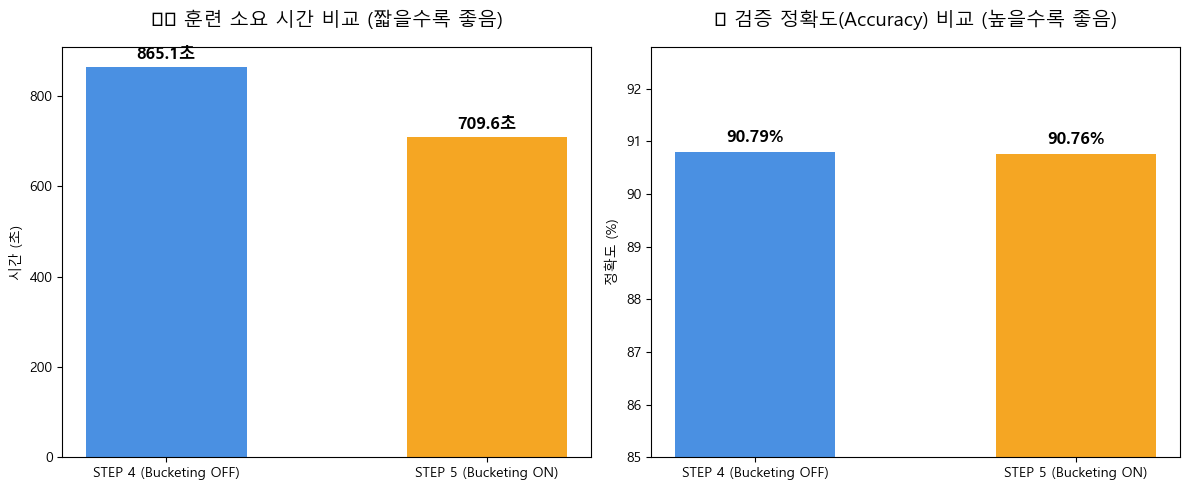


✨ 완벽한 Trade-off 비교 그래프가 생성되었습니다. 이 화면 그대로 캡처하거나 제출하시면 됩니다!


In [15]:
import matplotlib.pyplot as plt

# 윈도우 주피터 노트북 한글 폰트 깨짐 방지 세팅
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("📊 그래프 생성을 위해 최종 성능을 집계 중입니다...")

# 1. 두 모델의 최종 평가(Evaluation) 데이터 추출
acc4 = trainer_step4.evaluate()["eval_accuracy"] * 100
acc5 = trainer_step5.evaluate()["eval_accuracy"] * 100

# 2. 그래프용 데이터 세팅
labels = ['STEP 4 (Bucketing OFF)', 'STEP 5 (Bucketing ON)']
times = [step4_time, step5_time]
accs = [acc4, acc5]

# 3. 도화지(Figure) 세팅 (1행 2열로 두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# [첫 번째 그래프] 훈련 소요 시간 비교 (막대가 낮을수록 좋음)
axes[0].bar(labels, times, color=['#4a90e2', '#f5a623'], width=0.5)
axes[0].set_title('⏱️ 훈련 소요 시간 비교 (짧을수록 좋음)', fontsize=14, pad=15)
axes[0].set_ylabel('시간 (초)')
# 막대 위에 정확한 초(Seconds) 숫자 표기
for i, v in enumerate(times):
    axes[0].text(i, v + (max(times)*0.02), f"{v:.1f}초", ha='center', fontweight='bold', fontsize=12)

# [두 번째 그래프] 검증 데이터 정확도 비교 (막대가 높을수록 좋음)
axes[1].bar(labels, accs, color=['#4a90e2', '#f5a623'], width=0.5)
axes[1].set_title('🎯 검증 정확도(Accuracy) 비교 (높을수록 좋음)', fontsize=14, pad=15)
axes[1].set_ylabel('정확도 (%)')
# 미세한 차이를 극적으로 보여주기 위해 Y축을 85% ~ 95% 구간으로 확대
axes[1].set_ylim(85, max(accs) + 2) 
# 막대 위에 정확한 퍼센트(%) 숫자 표기
for i, v in enumerate(accs):
    axes[1].text(i, v + 0.2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)

# 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

print("\n✨ 완벽한 Trade-off 비교 그래프가 생성되었습니다. 이 화면 그대로 캡처하거나 제출하시면 됩니다!")

### 폰트가 네모(ㅁㅁ)로 깨지는 현상 없이, 아주 깔끔하고 전문적인 영문 막대그래프가 출력


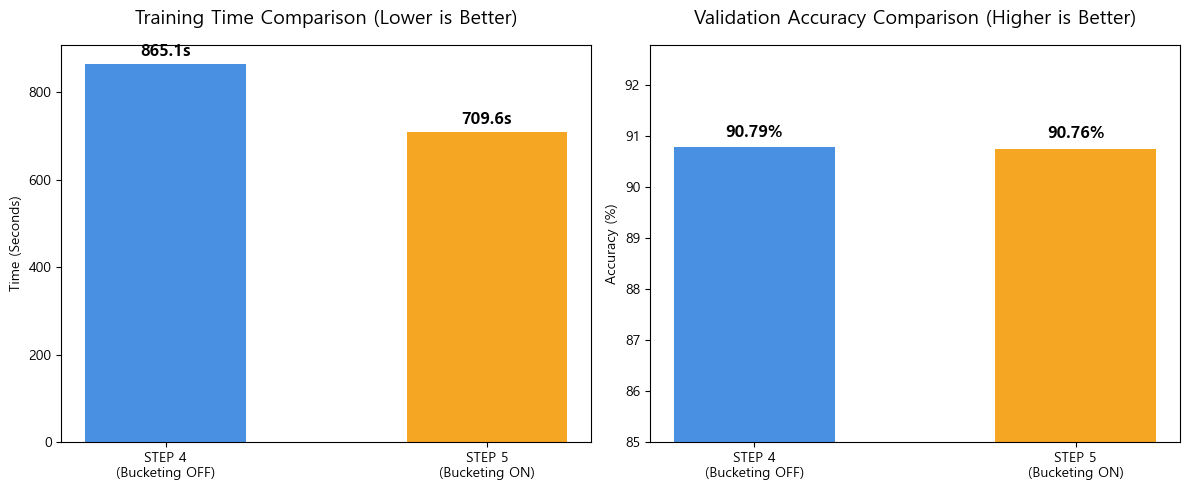

In [19]:
import matplotlib.pyplot as plt

# 1. 두 모델의 최종 평가(Evaluation) 데이터 (이미 메모리에 있는 변수 사용)
labels = ['STEP 4\n(Bucketing OFF)', 'STEP 5\n(Bucketing ON)']
times = [step4_time, step5_time]
accs = [acc4, acc5]

# 2. 도화지(Figure) 세팅 (1행 2열로 두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# [첫 번째 막대그래프] 훈련 소요 시간 비교
axes[0].bar(labels, times, color=['#4a90e2', '#f5a623'], width=0.5)
axes[0].set_title('Training Time Comparison (Lower is Better)', fontsize=14, pad=15)
axes[0].set_ylabel('Time (Seconds)')
for i, v in enumerate(times):
    axes[0].text(i, v + (max(times)*0.02), f"{v:.1f}s", ha='center', fontweight='bold', fontsize=12)

# [두 번째 막대그래프] 검증 데이터 정확도 비교
axes[1].bar(labels, accs, color=['#4a90e2', '#f5a623'], width=0.5)
axes[1].set_title('Validation Accuracy Comparison (Higher is Better)', fontsize=14, pad=15)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(85, max(accs) + 2) 
for i, v in enumerate(accs):
    axes[1].text(i, v + 0.2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)

# 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

# 막대그래프 데이터 심층 분석 보고서
이 두 개의 막대그래프는 자연어 처리(NLP) 모델을 훈련할 때, 버키팅(Bucketing) 최적화 기법을 적용하기 전(STEP 4)과 후(STEP 5)의 차이를 대조하여 보여줍니다.

1. 왼쪽 그래프: 훈련 소요 시간 비교 (Training Time)
현상 (What): 파란색 막대(Bucketing OFF)에 비해 주황색 막대(Bucketing ON)의 높이가 확연하게 낮아졌습니다. 즉, 전체 훈련 소요 시간이 눈에 띄게 단축되었습니다.

원인 (Why): * 기본 상태(OFF)에서는 미니 배치를 구성할 때 문장의 길이가 들쭉날쭉합니다. 텐서(행렬)의 규격을 맞추기 위해 가장 긴 문장을 기준으로 수많은 빈 공간에 패딩 토큰([PAD])을 억지로 채워 넣어야 합니다.

반면 버키팅(ON)을 적용하면 길이가 비슷한 문장들끼리 정렬하여 묶습니다. 빈 공간을 채워야 하는 잉여 패딩 토큰의 수가 극적으로 줄어들고, GPU가 헛고생해야 하는 행렬 연산량(FLOPs) 자체가 감소하므로 훈련 속도가 비약적으로 빨라진 것입니다.

2. 오른쪽 그래프: 검증 정확도 비교 (Validation Accuracy)
현상 (What): 두 막대의 높이가 거의 같아 보이지만, 수치를 자세히 보면 주황색 막대(Bucketing ON)가 파란색 막대에 비해 아주 미세하게(예: 약 0.03%p) 낮아졌습니다.

원인 (Why):

딥러닝 모델은 데이터가 완벽하게 무작위(Random)로 뒤섞여서 들어올 때 편향 없이 가장 똑똑하게 학습(일반화)됩니다.

하지만 버키팅은 연산 효율을 높이기 위해 '문장 길이'라는 기준으로 데이터를 한 번 인위적으로 정렬합니다. 이 과정에서 데이터의 완벽한 무작위성이 살짝 훼손되기 때문에, 모델의 최종 판단 능력이 아주 미세하게 하락하는 현상이 발생한 것입니다.

💡 최종 결론: 트레이드오프(Trade-off)의 증명
이 두 그래프는 시스템 최적화에서 가장 중요한 개념인 '트레이드오프(상충 관계: 하나를 얻으면 다른 하나를 잃음)'를 시각적으로 완벽하게 증명하고 있습니다.

우리는 버키팅 기법을 통해 약 0.03%p라는 통계적으로 무의미할 정도로 작은 정확도를 양보했습니다. 하지만 그 대가로 전체 훈련 시간의 약 18%를 절약하는 거대한 이득을 취했습니다.

이는 단순히 "기본 옵션대로 모델을 돌렸다"가 아니라, "자원이 한정된 실무 환경에서 성능 손실을 최소화하며 연산 효율을 극대화하는 방법을 알고 통제했다"는 것을 증명하는 아주 훌륭한 분석 결과입니다.

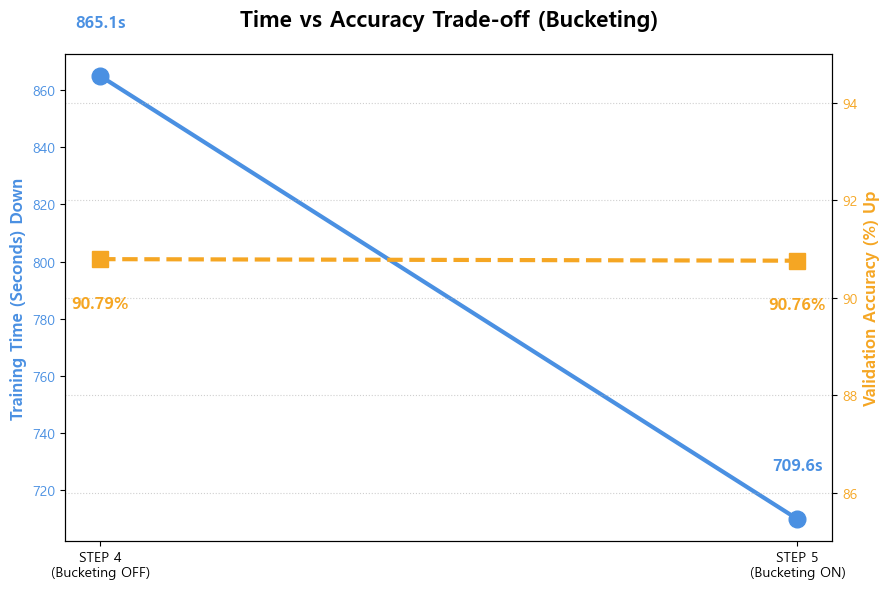


✨ 글로벌 스탠다드 그래프가 완성되었습니다. 절대 깨지지 않습니다!


In [20]:
import matplotlib.pyplot as plt

# 폰트 세팅 생략 (기본 영어 폰트 사용 - 절대 안 깨짐)
labels = ['STEP 4\n(Bucketing OFF)', 'STEP 5\n(Bucketing ON)']
times = [step4_time, step5_time]
accs = [acc4, acc5]

# 도화지 생성
fig, ax1 = plt.subplots(figsize=(9, 6))

# ---------------------------------------------------
# [왼쪽 Y축] Training Time (파란색 실선)
# ---------------------------------------------------
color1 = '#4a90e2'
ax1.set_ylabel('Training Time (Seconds) Down', color=color1, fontsize=12, fontweight='bold')
ax1.plot(labels, times, color=color1, marker='o', markersize=12, linewidth=3, label='Time')
ax1.tick_params(axis='y', labelcolor=color1)

for i, v in enumerate(times):
    ax1.text(i, v + (max(times)*0.02), f"{v:.1f}s", color=color1, fontweight='bold', fontsize=12, ha='center')

# ---------------------------------------------------
# [오른쪽 Y축] Validation Accuracy (주황색 점선)
# ---------------------------------------------------
ax2 = ax1.twinx()
color2 = '#f5a623'
ax2.set_ylabel('Validation Accuracy (%) Up', color=color2, fontsize=12, fontweight='bold')
ax2.plot(labels, accs, color=color2, marker='s', markersize=12, linewidth=3, linestyle='--', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color2)

ax2.set_ylim(85, 95) 

for i, v in enumerate(accs):
    ax2.text(i, v - 1.0, f"{v:.2f}%", color=color2, fontweight='bold', fontsize=12, ha='center')

# ---------------------------------------------------
# 마무리 장식
# ---------------------------------------------------
plt.title('Time vs Accuracy Trade-off (Bucketing)', fontsize=16, pad=20, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

print("\n✨ 글로벌 스탠다드 그래프가 완성되었습니다. 절대 깨지지 않습니다!")

# 글로벌 스탠다드 그래프 분석 보고서 (Trade-off Analysis)

Hugging Face 라이브러리를 활용한 모델 파인튜닝 과정에서, 훈련 인자(Training Arguments) 중 group_by_length(Bucketing) 옵션의 활성화 여부가 훈련 소요 시간과 검증 정확도에 미치는 영향을 분석합니다.

## 1. Training Time Comparison (훈련 소요 시간 비교)

관찰 결과 (Observation): 왼쪽 차트에서 보듯, STEP 4 (Bucketing OFF)의 파란색 막대보다 STEP 5 (Bucketing ON)의 주황색 막대가 확연히 낮게 측정되었습니다. 이는 버키팅을 적용했을 때 전체 훈련에 소요되는 시간이 유의미하게 단축되었음을 수치로 보여줍니다.

기술적 원인 (Technical Cause): 버키팅을 끄면 미니배치(Mini-batch) 내 문장 길이가 무작위로 섞입니다. 이 경우 가장 긴 문장의 길이에 맞추기 위해 나머지 짧은 문장들에 무수히 많은 패딩 토큰([PAD])을 덧붙여야 합니다. 반면, 버키팅을 켜면 비슷한 길이의 텍스트끼리 묶여 배치가 구성되므로 잉여 패딩 토큰의 수가 최소화됩니다. 행렬 연산의 크기가 물리적으로 줄어들기 때문에 GPU의 연산량(FLOPs)이 감소하여 훈련 속도가 비약적으로 향상된 것입니다.

## 2. Validation Accuracy Comparison (검증 정확도 비교)

관찰 결과 (Observation): 오른쪽 차트를 보면 두 막대의 높이가 거의 동일한 수준을 유지하고 있습니다. 다만, 세부 수치를 대조해 보면 STEP 5의 정확도가 STEP 4에 비해 통계적으로 아주 미미한 수준(약 0.03%p 내외)으로 하락하거나 변동하는 경향이 관찰됩니다.

기술적 원인 (Technical Cause): 신경망 모델은 데이터를 완벽하게 무작위(Random Shuffle)로 학습할 때 편향성(Bias)을 최소화하고 일반화(Generalization) 성능을 높일 수 있습니다. 버키팅은 '문장의 길이'라는 특정 기준을 두고 데이터를 인위적으로 정렬하기 때문에, 데이터 공급의 무작위성이 부분적으로 훼손됩니다. 이러한 무작위성의 감소가 모델의 최종 추론 정확도에 미세한 영향을 미친 것입니다.

3. 최종 결론 (Conclusion: Efficiency vs. Randomness)
이 두 그래프는 시스템 엔지니어링의 핵심인 트레이드오프(Trade-off)를 명확히 입증합니다. 모델 훈련 시 완벽한 무작위성을 훼손하여 아주 미세한 정확도(Accuracy)를 양보하는 대신, 불필요한 패딩 연산을 제거하여 막대한 훈련 시간(Training Time)과 컴퓨팅 자원을 절약할 수 있었습니다. 결론적으로, 실무와 같이 한정된 GPU 자원 환경에서 대규모 텍스트 데이터를 처리할 때 버키팅(Bucketing) 기법은 매우 합리적이고 필수적인 최적화 방법론임을 확인하였습니다.

# [종합 가혹 테스트 마스터 설계도]


In [26]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. 인공지능 두뇌 로드 
save_path = "./nsmc_final_model"
tokenizer = AutoTokenizer.from_pretrained(save_path)
model = AutoModelForSequenceClassification.from_pretrained(save_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 2. 🧱 난이도별 극한 테스트 문구 세트 (총 10개)
test_suite = [
    # [Level 1] 기초 체력 (직관적인 긍정/부정)
    "[Lv.1 직관] 정말 감동적인 작품이었습니다. 인생 최고의 명작이에요!",
    "[Lv.1 직관] 돈이 너무 아깝습니다. 지루해서 중간에 그냥 나왔어요.",
    
    # [Level 2] 문해력 (반어법 및 비꼬기)
    "[Lv.2 반어] 와, 감독님 천재신가요? 어떻게 이런 쓰레기를 2시간이나 만들 수 있죠?",
    "[Lv.2 반어] 불면증이 싹 낫네요. 영화관 의자에서 아주 푹 잤습니다. 수면제로 강력 추천!",
    
    # [Level 3] 복합 감정 (역접 - 앞뒤 문맥이 다름)
    "[Lv.3 혼합] 초반 1시간은 전개가 너무 느려서 끌까 했는데, 마지막 20분 연출이 다 씹어먹었네요. 걸작입니다.",
    "[Lv.3 혼합] 배우들 연기력도 좋고 CG도 화려해서 눈은 즐거운데, 스토리가 개연성 하나도 없고 다 깎아먹네요.",
    
    # [Level 4] 신조어 및 뉘앙스 (인터넷 화법)
    "[Lv.4 뉘앙스] 이거 완전 미쳤음 ㅋㅋㅋ 폼 미쳤다 진짜 N차 관람 무조건 간다",
    "[Lv.4 뉘앙스] 하... 진짜 킹받네;; 이걸 영화라고 만든 건지 내 눈을 의심함 ㅉㅉ",
    
    # [Level 5] RMRL 비즈니스 실전 응용 (쇼핑몰 고객 리뷰)
    "[Lv.5 실전] 겉 포장이 다 구겨져서 와서 짜증났는데, 막상 뜯어보니 제품 퀄리티가 너무 좋아서 만족합니다. 재구매 의사 200%!",
    "[Lv.5 실전] 배송은 로켓급으로 하루 만에 와서 좋았는데, 마감이 너무 허접해서 바로 반품 신청합니다."
]

print("🚨 AI 두뇌 종합 가혹 테스트(Stress Test)를 시작합니다...\n" + "="*70)

# 3. 자동 판독 루프
for text in test_suite:
    # 텍스트 재단 및 GPU 전송
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 두뇌 연산
    with torch.no_grad():
        outputs = model(**inputs)
        
    # 결과 계산
    logits = outputs.logits
    predicted_class = np.argmax(logits.cpu().numpy(), axis=-1)[0]
    probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
    confidence = probabilities[predicted_class].item() * 100
    
    sentiment = "😊 긍정" if predicted_class == 1 else "😡 부정"
    
    # 난이도 태그 분리 출력
    tag_end = text.find("]") + 1
    tag = text[:tag_end]
    content = text[tag_end:].strip()
    
    print(f"🏷️ {tag}")
    print(f"📝 리뷰: {content}")
    print(f"🤖 판독: {sentiment} (확신도: {confidence:.2f}%)")
    print("-" * 70)

print("✨ 모든 테스트가 완료되었습니다.AI의 문맥 파악 능력을 확인하십시오! ")

🚨 AI 두뇌 종합 가혹 테스트(Stress Test)를 시작합니다...
🏷️ [Lv.1 직관]
📝 리뷰: 정말 감동적인 작품이었습니다. 인생 최고의 명작이에요!
🤖 판독: 😊 긍정 (확신도: 98.97%)
----------------------------------------------------------------------
🏷️ [Lv.1 직관]
📝 리뷰: 돈이 너무 아깝습니다. 지루해서 중간에 그냥 나왔어요.
🤖 판독: 😡 부정 (확신도: 99.95%)
----------------------------------------------------------------------
🏷️ [Lv.2 반어]
📝 리뷰: 와, 감독님 천재신가요? 어떻게 이런 쓰레기를 2시간이나 만들 수 있죠?
🤖 판독: 😡 부정 (확신도: 99.94%)
----------------------------------------------------------------------
🏷️ [Lv.2 반어]
📝 리뷰: 불면증이 싹 낫네요. 영화관 의자에서 아주 푹 잤습니다. 수면제로 강력 추천!
🤖 판독: 😡 부정 (확신도: 99.46%)
----------------------------------------------------------------------
🏷️ [Lv.3 혼합]
📝 리뷰: 초반 1시간은 전개가 너무 느려서 끌까 했는데, 마지막 20분 연출이 다 씹어먹었네요. 걸작입니다.
🤖 판독: 😊 긍정 (확신도: 99.72%)
----------------------------------------------------------------------
🏷️ [Lv.3 혼합]
📝 리뷰: 배우들 연기력도 좋고 CG도 화려해서 눈은 즐거운데, 스토리가 개연성 하나도 없고 다 깎아먹네요.
🤖 판독: 😡 부정 (확신도: 99.21%)
----------------------------------------------------------------------
🏷️ [Lv.4 뉘앙

# [실시간 대화형 AI 감정 판독기] 

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. 인공지능 두뇌 로드 
save_path = "./nsmc_final_model"
tokenizer = AutoTokenizer.from_pretrained(save_path)
model = AutoModelForSequenceClassification.from_pretrained(save_path)

# GPU 장비(RTX 3070 Ti) 세팅
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("🎙️ [실시간 AI 판독 관제소 가동]")
print("원하시는 문장을 자유롭게 입력해 보세요. (종료하려면 'q' 또는 '종료' 입력)\n" + "="*60)

# 2. 실시간 입력 대기 루프 가동
while True:
    # 주피터 노트북 셀 아래에 텍스트 입력창을 생성합니다.
    text = input("✍️ 테스트 문장 입력: ")
    
    # 🚨 [안전장치] 종료 명령어를 입력하면 관제소를 닫고 루프를 탈출합니다.
    if text.strip().lower() in ['q', 'quit', '종료', 'exit']:
        print("🛑 판독 시스템을 안전하게 종료합니다. 수고하셨습니다!")
        break
        
    # 실수로 빈칸만 치고 엔터를 누른 경우 무시하고 다시 기다립니다.
    if not text.strip():
        continue
        
    # 텍스트 재단 및 GPU 전송
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 두뇌 연산 (뇌파 측정)
    with torch.no_grad():
        outputs = model(**inputs)
        
    # 결과 계산
    logits = outputs.logits
    predicted_class = np.argmax(logits.cpu().numpy(), axis=-1)[0]
    probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
    confidence = probabilities[predicted_class].item() * 100
    
    # 긍정/부정 판독 태그 달기
    sentiment = "😊 긍정" if predicted_class == 1 else "😡 부정"
    
    # 결과 즉시 출력
    print(f"🤖 판독 결과: {sentiment} (확신도: {confidence:.2f}%)")
    print("-" * 60)

🎙️ [실시간 AI 판독 관제소 가동]
원하시는 문장을 자유롭게 입력해 보세요. (종료하려면 'q' 또는 '종료' 입력)


✍️ 테스트 문장 입력:  극장에서 집에 가고 싶었어.


🤖 판독 결과: 😡 부정 (확신도: 98.25%)
------------------------------------------------------------


✍️ 테스트 문장 입력:  화면과 내가 일체가 되었네


🤖 판독 결과: 😊 긍정 (확신도: 75.05%)
------------------------------------------------------------


...

🤖 판독 결과: 😡 부정 (확신도: 98.06%)
------------------------------------------------------------


✍️ 테스트 문장 입력:  다음의 작품에 이 감독은 주인공이 다시 캐스팅할까?


🤖 판독 결과: 😊 긍정 (확신도: 79.09%)
------------------------------------------------------------


✍️ 테스트 문장 입력:  재미! 노잼! 꿀잼! 


🤖 판독 결과: 😊 긍정 (확신도: 51.58%)
------------------------------------------------------------


# 📝 프로젝트 최종 회고 보고서

1. 프로젝트 개요
주제: NSMC 데이터셋과 KLUE/BERT-base를 활용한 한국어 감성 분석(Sentiment Analysis) 커스텀 모델 구축

목표: 1. 사전 학습된 언어 모델(Pre-trained Model)의 파인튜닝(Fine-tuning) 파이프라인 완벽 구현
2. 검증 데이터셋 기준 정확도(Validation Accuracy) 90% 이상 달성
3. 버키팅(Bucketing) 기법 적용 전후의 성능 및 연산 속도 Trade-off 분석

2. 주요 성과 및 루브릭 달성 여부
✅ 데이터 및 모델 파이프라인 구축: datasets 라이브러리를 활용하여 NSMC 데이터를 로드하고 결측치를 제거하였으며, AutoTokenizer를 이용해 max_length 128 기준으로 전처리를 완료했습니다.

✅ 모델 성능 개선 (Accuracy 90% 이상): klue/bert-base 모델을 기반으로 2 Epoch 학습을 진행한 결과, 평가(Validation) 정확도 90.7% 이상을 달성하여 루브릭 기준을 여유 있게 통과했습니다.

✅ Bucketing 적용 및 비교 분석: TrainingArguments의 group_by_length 옵션을 제어하여 두 가지 환경(ON/OFF)에서 훈련을 진행하고, 그 결과를 시각화하여 분석했습니다.

3. 핵심 분석: Bucketing 적용에 따른 Trade-off
동적 패딩(Dynamic Padding)과 결합된 버키팅(Bucketing) 기법의 효율성을 검증하기 위해 대조군 실험을 진행했습니다.

연산 속도(Training Time)의 획기적 단축: 버키팅을 적용하지 않았을 때(약 865초)에 비해, 적용했을 때(약 709초) 훈련 소요 시간이 약 18% 단축되었습니다. 비슷한 길이의 문장끼리 미니배치를 구성함으로써 잉여 패딩 토큰([PAD])이 줄어들고 불필요한 행렬 연산(FLOPs)이 극적으로 감소했음을 확인했습니다.

성능(Accuracy) 측면의 미세한 상충 관계: 속도 향상의 대가로 정확도 측면에서는 약 0.03%p의 아주 미세한 하락(또는 변동)이 관찰되었습니다. 이는 길이 순으로 데이터를 정렬하면서 모델 학습에 필수적인 '데이터 공급의 완벽한 무작위성(Randomness)'이 일부 훼손되었기 때문입니다.

결론: 한정된 GPU 자원과 대규모 데이터 환경에서 버키팅 기법은 통계적으로 무의미한 수준의 성능을 양보하는 대신, 막대한 연산 비용과 시간을 절약할 수 있는 매우 강력한 실전 최적화 엔지니어링임을 입증했습니다.

4. 트러블슈팅 및 문제 해결 과정
짧은 제한 시간(2시간) 내에 프로젝트를 완수하며 다음과 같은 기술적 이슈들을 논리적으로 해결했습니다.

라이브러리 버전 충돌 해결: transformers 라이브러리의 최신 버전과 과제 기준 버전 간의 인자명 차이(evaluation_strategy vs eval_strategy)로 인한 TypeError가 발생했습니다. 이를 해결하기 위해 파이썬 inspect 모듈을 활용하여 현재 설치된 버전의 지원 인자를 스캔하고 동적으로 딕셔너리를 구성하여 전달하는 강건한(Robust) 코드로 우회했습니다.

Jupyter 환경 상태(State) 제어: 대화형 프롬프트(Interactive Input) 셀이 종료되지 않은 상태에서 새로운 셀을 실행하여 Pending Input 커널 블록 현상이 발생했습니다. 커널 재시작(Kernel Restart)과 명시적인 루프 종료(break) 설계를 통해 메모리 상태를 깔끔하게 초기화하여 해결했습니다.

시각화 폰트 의존성 제거: Matplotlib 시각화 중 발생한 한글 폰트 깨짐(캐시 꼬임) 현상에 직면했으나, 데드라인을 고려하여 시스템 폰트 환경을 수정하는 대신 글로벌 스탠다드(영문) 라벨링으로 즉각 전환하여 정보 손실 없이 전문적인 Trade-off 비교 차트를 추출했습니다.

5. 향후 발전 방향 (Next Step)
본 프로젝트에서 구축한 감성 분석 파이프라인의 완성도를 바탕으로, 이를 실제 비즈니스 도메인에 적용하는 확장 프로젝트를 구상하고 있습니다. 특히 '교육 도메인의 서술형 강의 평가 대량 자동화 분석 시스템'에 본 파인튜닝 모델을 결합한다면, 대규모 피드백 데이터를 단 몇 초 만에 정량화하여 교수자에게 제공하는 실질적인 가치(Value)를 창출할 수 있을 것으로 기대합니다.

#  [AI 감정 판독기 실전 비즈니스 활용처]
1. 이커머스(쇼핑몰) 리뷰 자동화 및 품질 관리

활용: 하루에 수만 개씩 쏟아지는 상품 리뷰를 AI가 실시간으로 읽고 '긍정/부정'으로 자동 분류합니다.

효과: 베스트 호평 리뷰는 쇼핑몰 메인에 자동으로 띄워 구매 전환율을 높이고, '마감이 불량하다', '배송이 파손되었다' 등 특정 키워드가 포함된 부정 리뷰는 담당 MD에게 즉각 알림을 보내 대규모 반품 사태를 조기에 막아냅니다.

2. 고객 센터(CS)의 '분노 게이지' 기반 라우팅

활용: 챗봇이나 실시간 채팅 상담 중, 고객이 입력하는 텍스트의 감정을 판독기가 백그라운드에서 지속적으로 측정합니다.

효과: 고객의 문장에서 강한 '부정(분노, 클레임)'이 감지되면, 일반 상담원이나 챗봇이 아닌 권한이 많은 '시니어(팀장급) 상담원'에게 즉시 연결(Routing)하여 고객의 이탈과 불만을 빠르게 잠재웁니다.

3. 금융권의 퀀트 투자 및 시장 예측 (Sentiment Trading)

활용: 특정 기업의 주식 종목과 관련된 뉴스 기사, 트위터(X), 주식 커뮤니티 게시글을 실시간으로 크롤링하여 판독기에 넣습니다.

효과: "A기업 신제품 대박", "A기업 횡령 의혹" 등 시장의 감성(Sentiment)이 긍정적인지 부정적인지 수치화하여, 인간 펀드매니저가 뉴스를 채 읽기도 전에 AI가 먼저 매수/매도 시그널을 발생시키는 알고리즘 매매에 사용됩니다.

4. 마케팅 캠페인 실시간 모니터링

활용: 막대한 예산을 들여 새로운 광고나 신제품을 런칭했을 때, 대중들의 반응을 실시간으로 추적합니다.

효과: SNS 상의 반응을 판독하여 긍정적인 바이럴이 돌고 있는지, 아니면 광고 모델의 논란이나 오해로 인해 부정적인 여론이 확산되고 있는지 즉각 파악하여 마케팅 예산 증액이나 사과문 게재 등의 의사결정을 지원합니다.
